In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
from jax import config
config.update("jax_enable_x64", True)

In [21]:
# Define the action
class ScalarAction(lhmc.Action):
    @staticmethod
    @jax.jit
    def _Sjax(phi, kappa, lamb):
        S = phi**2
        
        for ax in range(d):
            S -= 2 * kappa * phi * phi.nn_field(ax)

        S += lamb * (phi**2 - 1)**2    
        return S
    
    def _compute_forces(self):
        self.grads = {
            'phi': jax.jit(jax.grad(lambda phi, kappa, lamb: jnp.sum(self._Sjax(phi, kappa, lamb).field))),
        }

        def force_func(fields):
#            return {'phi': self.exact_force(fields['phi'], self.params['kappa'], self.params['lamb'])}
            return {'phi': self.grads['phi'](fields['phi'], self.params['kappa'], self.params['lamb']) }

        self.forces = force_func
    
    @staticmethod
    @jax.jit
    def exact_force(phi, kappa, lamb):
        J = phi.nn_field(axis=0, shift=1) + phi.nn_field(axis=0, shift=-1)
        for ax in range(1,d):
            J += phi.nn_field(axis=ax, shift=1)
            J += phi.nn_field(axis=ax, shift=-1)

        F = -2 * kappa * J
        F += 2 * phi.field
        F += 4 * lamb * (phi.field**2 - 1) * phi.field

        return lat.LatticeField(lattice=phi.lattice, field=F, bc=phi.bc)
            
    
    def _S(self):
        return self._Sjax(self.fields['phi'], self.params['kappa'], self.params['lamb'])



In [22]:
jnp.sum(S4._Sjax(phi4, 0.1, 0.1).field)

Array(51.2, dtype=float64)

In [3]:
print(phi4.field[0,0,0,0])

test_force_1 = S4.forces({'phi': phi4})['phi'].field
print(test_force_1[0,0,0,0])

test_force_2 = S4.exact_force(phi4, S4.params['kappa'], S4.params['lamb'])
print(test_force_2.field[0,0,0,0])

jnp.sum(test_force_2.field + (-1)*test_force_1)

NameError: name 'phi4' is not defined

In [23]:
# First test case: exercise 2.5
d = 4
Lat4 = lat.SquareLattice(dims=((4,)*d))
phi4 = lat.LatticeField(Lat4)
phi4.field = np.ones_like(phi4.field)

S4 = ScalarAction({'phi': phi4}, params={'kappa': 0.18169, 'lamb': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC_leap = lhmc.HMCEvolver(
        action=S4,
        seed=7245,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    HMC_om = lhmc.HMCEvolver(
        action=S4,
        seed=8735,
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )
    for _ in range(1000):
        HMC_leap.evolve(warmup=True)
        HMC_om.evolve(warmup=True)

    abs_dH_leap = np.abs(np.array(HMC_leap.monitor['delta_H']))
    abs_dH_om = np.abs(np.array(HMC_om.monitor['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))


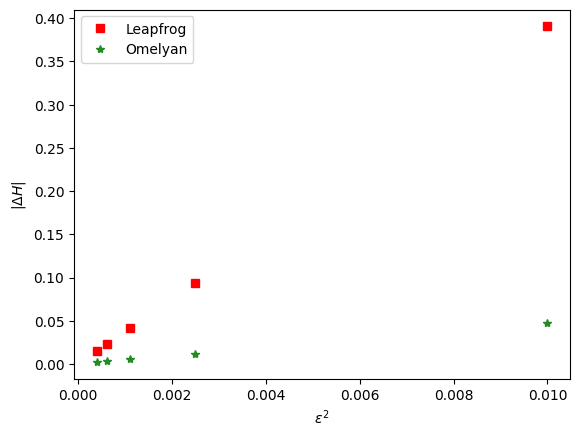

In [24]:
#Figure 2.2
plt.plot(all_eps**2, gv.mean(all_dH_leap), ls=' ', marker='s', color='red', label='Leapfrog')
plt.plot(all_eps**2, gv.mean(all_dH_om), ls=' ', marker='*', color='forestgreen', label='Omelyan')

plt.xlabel('$\epsilon^2$')
plt.ylabel('$|\Delta H|$')
plt.legend()

Another technical plot first: let's do figure 2.4.

In [25]:
# First test case: exercise 2.5
d = 4
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
#phi6.field = np.ones_like(phi6.field)

S6 = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

all_Nstep = np.array([5, 7, 8, 10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_acc_rate = []

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC = lhmc.HMCEvolver(
        action=S4,
        seed=7245,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )

    for _ in range(1000):
        HMC.evolve(warmup=False)

    all_acc_rate.append(np.mean(np.array(HMC.monitor['accept'])))
    

Text(0, 0.5, 'acc rate')

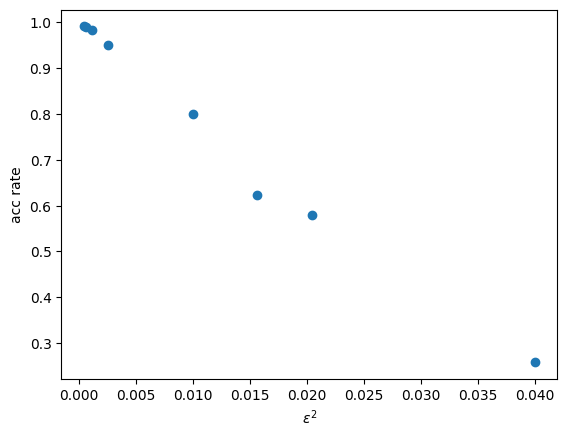

In [26]:
plt.plot(all_eps**2, all_acc_rate, ls=' ', marker='o')

plt.xlabel('$\epsilon^2$')
plt.ylabel('acc rate')

Text(0, 0.5, '$1/\\epsilon/$ acc rate [cost]')

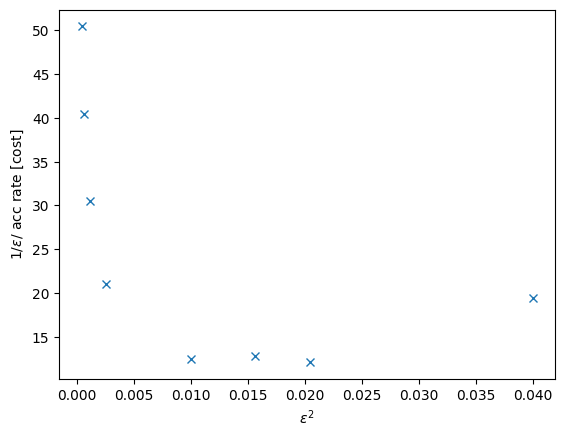

In [27]:
plt.plot(all_eps**2, 1/all_eps/all_acc_rate, ls=' ', marker='x')
plt.xlabel('$\epsilon^2$')
plt.ylabel('$1/\epsilon/$ acc rate [cost]')

Now on to figure 2.3 and comparing HMC to MD.

In [28]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.field)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [29]:
%%prun -s cumulative

# Second test case: figure 2.3
d = 3
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
phi6.field = np.ones_like(phi6.field)

#S6_HMC = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})
#S6_HMD = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

all_Nstep = np.array([4,5,6,7,8,10])
#all_Nstep = np.array([50, 100])
all_eps = 1/all_Nstep
m2_HMC = []
m2_HMD = []

for eps, Nstep in zip(all_eps, all_Nstep):
    print(eps, Nstep)

    # WARNING: instantiating both from the same action object causes
    # exchange of information between the two HMCEvolvers!
    # 
    # I should figure out a clean fix to this...
    #

    #S6_HMC.fields['phi'] = phi6.copy()
    #S6_HMD.fields['phi'] = phi6.copy()
    
    HMC = lhmc.HMCEvolver(
        action=ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689}),
        seed=73645+Nstep,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
        observables={'mag': (mag_obs, 1)},
    )
    HMD = lhmc.HMCEvolver(
        action=ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689}),
        seed=86735+Nstep,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
        observables={'mag': (mag_obs, 1)},
    )

#    for _ in range(200):
#        HMC.evolve(warmup=True)
#        HMD.evolve(warmup=True)

#    HMC.obs_chain = {'mag': []}
#    HMD.obs_chain = {'mag': []}
    
    for _ in range(500):
        HMC.evolve(warmup=False)
        HMD.evolve(warmup=True)

    raw_m2_HMC = (np.array(HMC.obs_chain['mag'])[:,1])/6**d
    raw_m2_HMD = (np.array(HMD.obs_chain['mag'])[:,1])/6**d

    m2_HMC.append(gv.dataset.avg_data(raw_m2_HMC))
    m2_HMD.append(gv.dataset.avg_data(raw_m2_HMD))


0.25 4
0.2 5
0.16666666666666666 6
0.14285714285714285 7
0.125 8
0.1 10
 

         3369650 function calls (3346837 primitive calls) in 4.856 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    4.946    4.946 {built-in method builtins.exec}
        1    0.021    0.021    4.946    4.946 <string>:1(<module>)
     6000    0.396    0.000    4.887    0.001 hmc.py:398(evolve)
   354/29    0.001    0.000    3.030    0.104 traceback_util.py:173(reraise_with_filtered_traceback)
   288/29    0.001    0.000    3.030    0.104 pjit.py:253(cache_miss)
   288/29    0.002    0.000    3.029    0.104 pjit.py:160(_python_pjit_helper)
9477/8611    0.015    0.000    3.024    0.000 core.py:388(bind_with_trace)
2544/2120    0.015    0.000    2.996    0.001 profiler.py:311(wrapper)
  445/265    0.001    0.000    2.831    0.011 core.py:2598(bind)
     8227    0.008    0.000    2.820    0.000 core.py:820(process_primitive)
       29    0.001    0.000    2.661    0.092 pjit.py:1194(_pjit_call_im

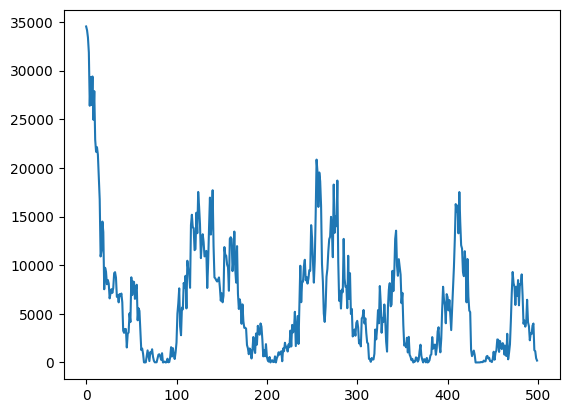

In [30]:
mtest = np.array(HMD.obs_chain['mag'])
plt.plot(mtest[:,1])

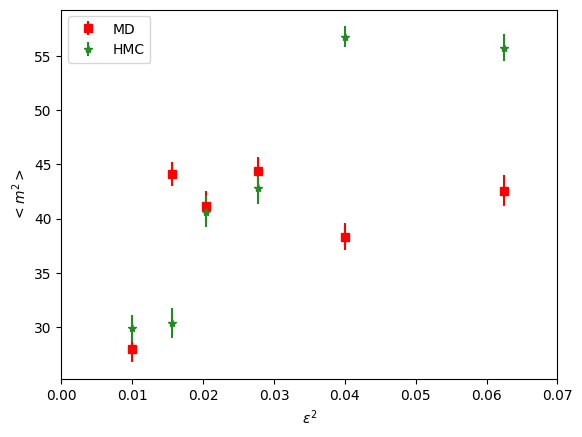

In [31]:
plt.errorbar(all_eps**2, gv.mean(m2_HMD), gv.sdev(m2_HMD), ls=' ', marker='s', color='red', label='MD')
plt.errorbar(all_eps**2, gv.mean(m2_HMC), gv.sdev(m2_HMC), ls=' ', marker='*', color='forestgreen', label='HMC')


plt.xlim(0,0.07)
plt.xlabel('$\epsilon^2$')
plt.ylabel('$<m^2>$')
plt.legend()

Finally the big physics result, figure 2.5!

In [60]:
from tqdm import tqdm

d = 3

all_kappa = np.array([0.05, 0.10, 0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22])
all_L = (6,8,10)

mag_k = {}

for L in tqdm(all_L):
    mag_k[L] = []

    Lat = lat.SquareLattice(dims=((L,)*d))
    phi = lat.LatticeField(Lat)

    for k in all_kappa:
        S6 = ScalarAction({'phi': phi}, params={'kappa': k, 'lamb': 1.1689})
    
        HMC = lhmc.HMCEvolver(
            action=S6,
            seed=72645,
            integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
            observables={'mag': (mag_obs, 10)},
        )
    
        for _ in range(100):
            HMC.evolve(warmup=True)
    
        for _ in range(2000):
            HMC.evolve()
    
        raw_m = np.abs(np.array(HMC.obs_chain['mag'])[10:,0])/L**d
    
        mag_k[L].append(gv.dataset.avg_data(raw_m))
    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:31<00:00, 10.64s/it]


(0.15, 0.22)

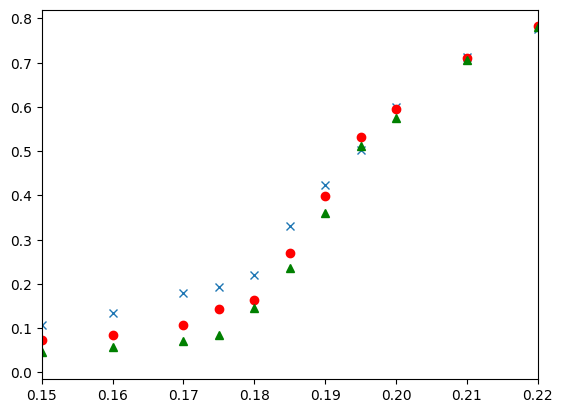

In [61]:
plt.plot(all_kappa, gv.mean(mag_k[6]), ls=' ', marker='x')
plt.plot(all_kappa, gv.mean(mag_k[8]), ls=' ', marker='o', color='red')
plt.plot(all_kappa, gv.mean(mag_k[10]), ls=' ', marker='^', color='green')

plt.xlim(0.15, 0.22)